## Problem Statement

Customer churn occurs when customers stop using a company's services. In the telecom industry, churn can lead to significant revenue loss.

The goal of this project is to build a machine learning model that predicts whether a customer will churn based on their service usage, billing information, and demographic data. By predicting churn early, companies can take actions such as offering discounts or improving services to retain customers.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score,accuracy_score,classification_report,confusion_matrix
from sklearn.ensemble import RandomForestClassifier


## Data Loading

The dataset used in this project is the **IBM Telco Customer Churn dataset**. It contains information about telecom customers such as contract type, internet services, monthly charges, and whether the customer churned.

The dataset contains **7043 rows and 21 columns**. We load the dataset using the pandas library and inspect its structure before performing further analysis.


In [2]:
data=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(data.shape)

print(data.info())
display(data.describe())
data.head()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) helps us understand the dataset and identify patterns related to customer churn.

In this step we analyze:

* Distribution of churned vs non-churned customers
* Relationship between contract type and churn
* Relationship between payment method and churn
* Effect of tenure and monthly charges on churn

These insights help us understand which factors may influence customer churn.


Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


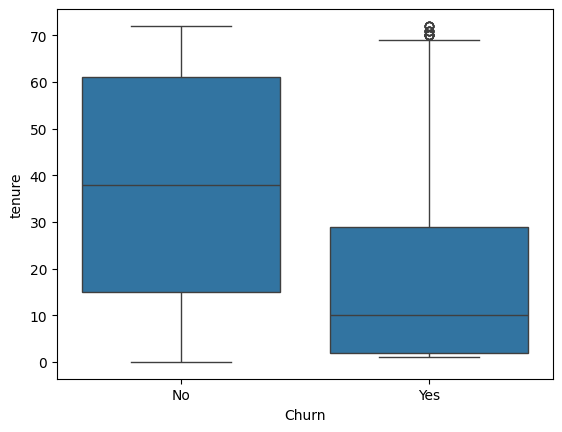

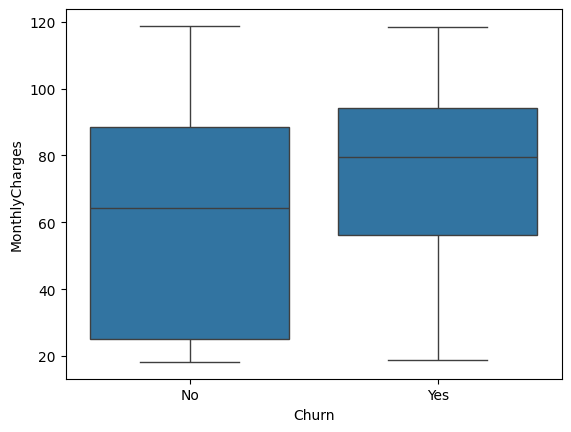

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [3]:
data['Churn'].value_counts()
pd.crosstab(data['Contract'],data['Churn'])
print(pd.crosstab(data['Contract'],data['Churn'],normalize='index')*100)
pd.crosstab(data['PaymentMethod'],data['Churn'])
(pd.crosstab(data['PaymentMethod'],data['Churn'],normalize='index')*100)
sns.boxplot(x='Churn',y='tenure',data=data)
plt.show()
sns.boxplot(x='Churn',y='MonthlyCharges',data=data)
plt.show()
data.isnull().sum()

## Data Cleaning

During inspection of the dataset, we identified an issue in the **TotalCharges** column. Some rows contained blank values and the column was stored as an object type instead of numeric.

To fix this:

* Blank values were replaced with missing values
* Rows containing missing values were removed
* The column was converted to numeric format

The **customerID** column was also removed because it is only an identifier and does not help in predicting churn.


In [4]:
data.dtypes
data['TotalCharges'].unique()
(data['TotalCharges']==' ').sum()
data[data['TotalCharges']==' ']
data['TotalCharges']=data['TotalCharges'].replace(' ',None)
data=data.dropna()
data['TotalCharges']=pd.to_numeric(data['TotalCharges'])
data.dtypes
data['Churn']=data['Churn'].map({'Yes':1,'No':0})
print(data['Churn'].unique())
data.shape
data=data.drop('customerID',axis=1)
X=data.drop('Churn',axis=1)
y=data['Churn']

[0 1]


## Feature Engineering

Before training the model, we prepared the dataset by separating the input features and the target variable.

The **Churn** column was converted into a binary format:

* 1 → Customer churned
* 0 → Customer stayed

This allows machine learning models to process the target variable correctly.


In [5]:
X=data.drop('Churn',axis=1)
y=data['Churn']

## Encoding Categorical Variables

Many columns in the dataset contain categorical values such as contract type and payment method. Since machine learning models require numerical inputs, these categorical features were converted into numerical values using **One-Hot Encoding**.

This transformation allows the model to understand categorical information without creating artificial ordering between categories.


In [6]:

cat_cols=X.select_dtypes(include='object').columns
encoder=OneHotEncoder(drop='first',sparse_output=False)
encoded=encoder.fit_transform(X[cat_cols])
encoded_df=pd.DataFrame(encoded,columns=encoder.get_feature_names_out(cat_cols))
X=X.drop(cat_cols,axis=1)
X=pd.concat([X.reset_index(drop=True),encoded_df],axis=1)
X.head()
X.shape


(7032, 30)

## Train-Test Split

To evaluate the model properly, the dataset was divided into two parts:

* **Training set (80%)** used to train the model
* **Testing set (20%)** used to evaluate model performance

This ensures the model is tested on unseen data and prevents overfitting.


In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Logistic Regression Model

Logistic Regression was used as the first model for churn prediction. It is a simple and commonly used algorithm for classification problems.

The model estimates the probability that a customer will churn based on the input features. Logistic Regression provides a good baseline model to compare with other algorithms.


In [8]:
model=LogisticRegression(max_iter=5000,class_weight='balanced',solver='lbfgs')
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
acc=accuracy_score(y_test,y_pred)
print(acc)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))



0.7313432835820896
[[733 300]
 [ 78 296]]
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



## Random Forest Model

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their results to improve prediction accuracy.

It is capable of capturing complex relationships between features and generally performs better than a single decision tree. In this project, Random Forest is used to compare performance with Logistic Regression.


In [9]:
rf=RandomForestClassifier(n_estimators=200,random_state=42,class_weight='balanced')
rf.fit(X_train,y_train)
y_predrf=rf.predict(X_test)
print(accuracy_score(y_test,y_predrf))
print(confusion_matrix(y_test,y_predrf))
print(classification_report(y_test,y_predrf))

0.7846481876332623
[[933 100]
 [203 171]]
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.46      0.53       374

    accuracy                           0.78      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



## Model Evaluation

To evaluate model performance, we used several classification metrics:

* **Accuracy** – overall correctness of predictions
* **Confusion Matrix** – shows correct and incorrect predictions
* **Precision, Recall, and F1-Score** – provide deeper insight into model performance

These metrics help us understand how well the model predicts customer churn.


In [10]:
results=pd.DataFrame({
    'model':['LogisticRegression','RandomForestClassifier'],
     "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_predrf)
    ]
})
print(results)

                    model  Accuracy
0      LogisticRegression  0.731343
1  RandomForestClassifier  0.784648


## Feature Importance

Feature importance helps identify which variables contribute most to predicting customer churn.

Using the Random Forest model, we calculated the importance of each feature. Features with higher importance have a stronger influence on the model’s predictions.

Key factors influencing churn include contract type, tenure, and monthly charges.


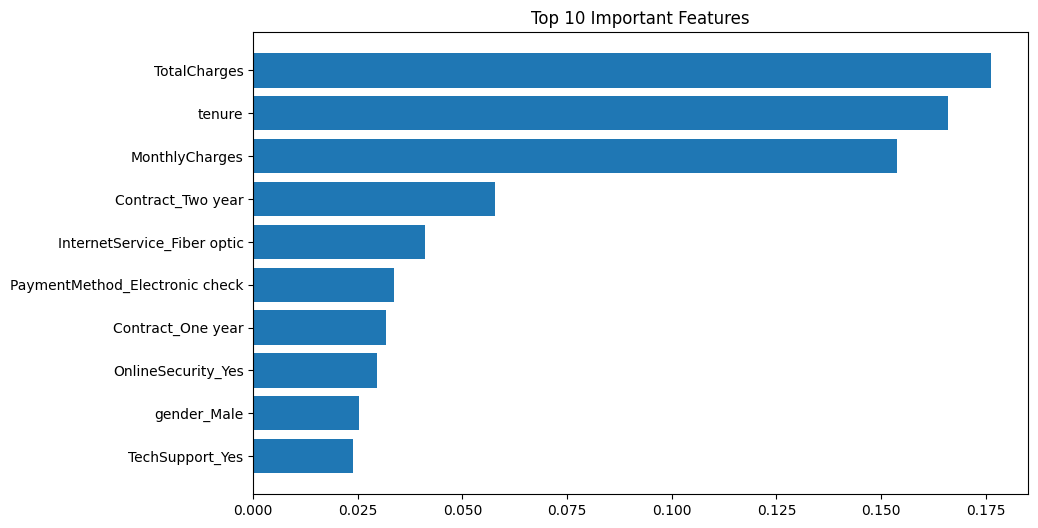

In [11]:
feature_importances = rf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"][:10], importance_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()


# Business Insights

Key insights from the analysis:

1. Customers with month-to-month contracts churn more frequently.
2. Customers with lower tenure are more likely to leave.
3. Higher monthly charges are associated with higher churn.
4. Contract type is one of the strongest predictors of churn.

Recommendations:
- Encourage customers to move to longer-term contracts.
- Offer retention incentives to new customers.
- Monitor customers with high monthly charges.






## Conclusion

In this project, two machine learning models were used to predict customer churn: Logistic Regression and Random Forest.

The Random Forest model achieved a higher overall accuracy of approximately **78%**, compared to **73%** for Logistic Regression. This means Random Forest was slightly better at correctly classifying customers overall.

However, when analyzing the classification metrics more closely, Logistic Regression showed a **much higher recall for churned customers (0.79)** compared to Random Forest (0.46). Recall measures how well the model identifies customers who are actually going to churn.

This is an important metric for churn prediction because missing churned customers may result in revenue loss for the company.

The analysis also revealed that factors such as **contract type, customer tenure, and monthly charges** have a strong influence on customer churn.

Overall, this project demonstrates how machine learning models can help telecom companies identify customers who are likely to leave and take proactive actions such as retention offers or improved services to reduce churn.

